In [39]:
import numpy as np


In [112]:
from transformers import ViTImageProcessor, ViTModel
from PIL import Image
import requests

# url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
# image = Image.open(requests.get(url, stream=True).raw)

url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
# image = Image.open('faces_vase_color.jpg')
image = Image.open('ondergaande_zon_klein.jpeg')

processor = ViTImageProcessor.from_pretrained('google/vit-large-patch16-224-in21k')
model = ViTModel.from_pretrained('google/vit-large-patch16-224-in21k')

inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs, output_hidden_states=True)

# hidden_states is a tuple of (embeddings + all layer outputs)
all_hidden_states = outputs.hidden_states

# Example: Totally 25 layers: take middle layer 13
# Totally 24 layers: take 12
if len(all_hidden_states) % 2:
    middle_layer_number = int((len(all_hidden_states) + 1 )/ 2)
else:
    middle_layer_number = int(len(all_hidden_states) / 2)
    # or maybe +1?
middle_layer_output = all_hidden_states[middle_layer_number]

print(f"Number of layers: {len(all_hidden_states)}")
print(f"Shape of middle layer {middle_layer_number}: {middle_layer_output.shape}")

last_hidden_state = outputs.last_hidden_state

Loading weights: 100%|██████████| 392/392 [00:00<00:00, 5758.28it/s]


Number of layers: 25
Shape of middle layer 13: torch.Size([1, 197, 1024])


In [142]:
image.size

(320, 196)

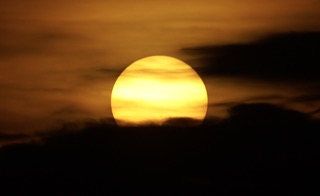

In [113]:
image

In [114]:
from sklearn.decomposition import PCA
X = middle_layer_output.detach().numpy()[0] #Tensor with activations from the middle layer

pca = PCA(n_components=1)
pca.fit(X)
print(pca.explained_variance_ratio_)
print(pca.singular_values_)

[0.9747494]
[2654.7659]


In [115]:
pca.components_

array([[ 0.00142395,  0.0006896 , -0.0003295 , ...,  0.00050743,
         0.00056683, -0.00061237]], shape=(1, 1024), dtype=float32)

In [116]:
pca.components_.shape

(1, 1024)

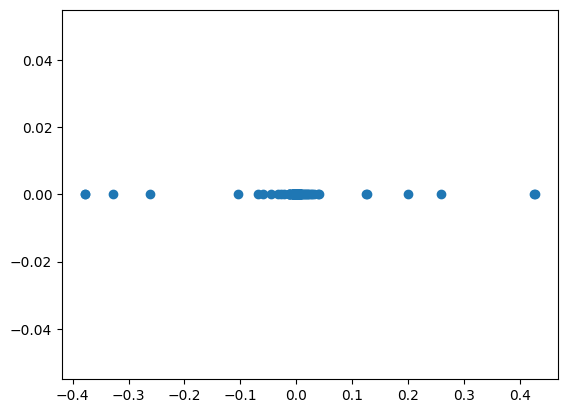

In [117]:
import matplotlib.pyplot as plt


plt.scatter(pca.components_[0, :], np.zeros(len(pca.components_[0])))


In [118]:
# 1. Select the first component (eigenvector)
first_component = pca.components_[0] # Shape: (n_features,)

# 2. Project data (n_samples, 1) using the component
X_reduced = pca.transform(X)[:, 0].reshape(-1, 1)

# 3. Reconstruct: X_orig = (Reduced_Data * Components) + Mean
# Note: Transpose first_component for matrix multiplication
reconstruction = np.dot(X_reduced, first_component.reshape(1, -1)) + pca.mean_

In [119]:
reconstruction

array([[ 0.16012457,  0.98327184,  0.21638392, ..., -0.14946206,
        -0.00857328, -0.27876067],
       [ 0.16090225,  0.9836484 ,  0.21620396, ..., -0.14918493,
        -0.00826371, -0.2790951 ],
       [ 0.16092345,  0.98365873,  0.21619906, ..., -0.14917737,
        -0.00825526, -0.27910423],
       ...,
       [ 0.15399428,  0.980303  ,  0.21780244, ..., -0.15164658,
        -0.01101357, -0.27612433],
       [ 0.15777381,  0.9821334 ,  0.21692787, ..., -0.15029974,
        -0.00950905, -0.27774972],
       [ 0.16109976,  0.9837441 ,  0.21615826, ..., -0.14911455,
        -0.00818508, -0.27918005]], shape=(197, 1024), dtype=float32)

In [140]:
reconstruction.reshape(32,32)

ValueError: cannot reshape array of size 201728 into shape (32,32)

In [120]:
doe_die_image = first_component.reshape(32,32)

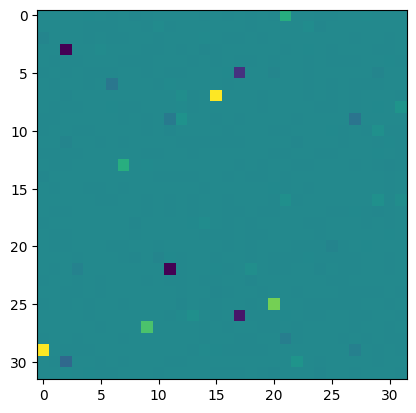

In [139]:
plt.imshow(doe_die_image, interpolation=None)
plt.show()


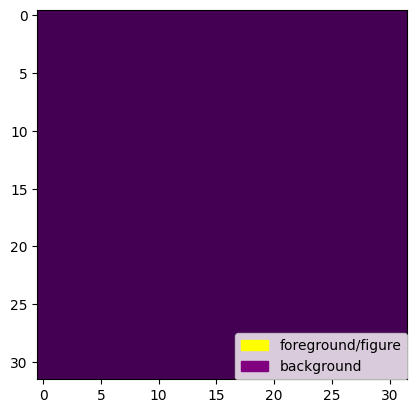

In [137]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

## color map and labels
t = 1 ## alpha value
cmap = {0:[1.0,1.0,0.0],1:[0.5,0.0,0.5]}
labels = {0:'foreground/figure',1:'background'}
arrayShow = np.where(
    doe_die_image > 0.5,
    0,
    1,)
## create patches as legend
patches =[mpatches.Patch(color=cmap[i],label=labels[i]) for i in cmap]

plt.imshow(arrayShow)
plt.legend(handles=patches, loc=4, borderaxespad=0.)
plt.show()


In [124]:
arrayShow

array([[0, 0, 1, ..., 1, 0, 0],
       [0, 1, 0, ..., 0, 1, 0],
       [1, 0, 1, ..., 0, 1, 1],
       ...,
       [0, 0, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 0, 1],
       [0, 0, 0, ..., 0, 0, 1]], shape=(32, 32))